# Assignment 3

- Go back to Lab assignment 2 and improve the LR result based on the extensions of LR
- Classify the weakest link based on the 38 predictors of a movement using a few classification variants(different models or model parameterizations)
- Select an accuracy metric
- Test and iteratively improve the accuracy of the variants

## Imports

In [159]:
import sys

sys.path.append("../../scripts")

import dagshub
import mlflow
import ml_utils as mlutils

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import ExtraTreesClassifier



## Setup

In [160]:
# Setup dagshub and MLFlow

dagshub.init(repo_owner="SamuelFredricBerg", repo_name="4dt907", mlflow=True)
utils = mlutils.mlutils("Project_Model_A3_V2")

# Configs
config = {
    "data_split_seed": 42,
    "test_size": 0.2,
    "n_folds": 10,
    "shuffle": True,
    "variant": "A3-Stacking-Stratified-OversamplingLimit",
    
    # Base Model Params
    "n_estimators": 300,        # Increased for better convergence
    "max_depth": 12,            # Added depth to capture complex non-linearities
    "class_weight": "balanced_subsample", # Essential for 14-class imbalance
    
    # Stacking Logic
    "passthrough": True,         # Set to True to let meta-learner see raw movement features
    "min_max_oversample": 50
}

WeakLink_data_path = "../../data/AimoScore_WeakLink_big_scores_A3.csv"
Scores_data_path = "../../data/scores_and_weak_links_A3.csv"

dfw = pd.read_csv(WeakLink_data_path)
dfs = pd.read_csv(Scores_data_path)


df_final = pd.merge(dfw, dfs, on="ID")


weak_link_columns = [
    'ForwardHead', 'LeftArmFallForward', 'RightArmFallForward',
    'LeftShoulderElevation', 'RightShoulderElevation', 'ExcessiveForwardLean',
    'LeftAsymmetricalWeightShift', 'RightAsymmetricalWeightShift',
    'LeftKneeMovesInward', 'RightKneeMovesInward', 'LeftKneeMovesOutward',
    'RightKneeMovesOutward', 'LeftHeelRises', 'RightHeelRises'
]

df_final['WeakestLink'] = df_final[weak_link_columns].idxmax(axis=1)


kf = StratifiedKFold(
    n_splits=config["n_folds"],
    shuffle=config["shuffle"],
    random_state=config["data_split_seed"],
)

Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

# Preprocessing

In [161]:
def preprocessing(df):
    df_new = df.copy()
    
    # Mapping your Symmetric NASM/FMS features
    # FMS Pairs: [4 6], [5 7], [8 11], [9 12], [10 13]
    # NASM Pairs: [14 15], [17 18], [21 22], [24 25], [26 27], [28 29], [31 32]
    
    pairs = [
        (4, 6), (5, 7), (8, 11), (9, 12), (10, 13),      # FMS
        (14, 15), (17, 18), (21, 22), (24, 25), (26, 27), (28, 29), (31, 32) # NASM
    ]
    
    for left_idx, right_idx in pairs:
        l_col = f'No_{left_idx}_Angle_Deviation'
        r_col = f'No_{right_idx}_Angle_Deviation'
        
        if l_col in df_new.columns and r_col in df_new.columns:
            # Create a new feature representing the symmetry gap
            df_new[f'Diff_{left_idx}_{right_idx}'] = df_new[l_col] - df_new[r_col]
            
    return df_new

In [ ]:
from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

from sklearn.pipeline import FunctionTransformer

from sklearn.compose import ColumnTransformer

def fit_stacking_classifier(X, y, kf_object):
    strategy = {k: max(v, config["min_max_oversample"]) for k, v in Counter(y).items()}
    
    # 1. This step adds the 4 'Diff' columns (Total: 42 features)
    # It works on the DataFrame while names still exist!

    # 2. Define the layers as before
    base_layers = [
        ('rf', RandomForestClassifier(n_estimators=config["n_estimators"], max_depth=config["max_depth"], class_weight=config["class_weight"], random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=config["n_estimators"], bootstrap=True, class_weight=config["class_weight"], random_state=42)),
        ('nb', GaussianNB()),
        ('lr', make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=5000)))
    ]
    
    stack_model = StackingClassifier(
        estimators=base_layers,
        final_estimator=LogisticRegression(penalty='l2', C=1.0),
        cv=kf_object,
        passthrough=config["passthrough"]
    )

    return ImbPipeline([
        ('oversample', RandomOverSampler(sampling_strategy=strategy, random_state=42)),
        ('stack', stack_model)
    ])

In [163]:
def report_oversampling(X, y):
    """Generates a report using the custom 'Floor' strategy."""
    original_counts = Counter(y)
    
    # Calculate the strategy dictionary based on your config floor
    strategy = {k: max(v, config["min_max_oversample"]) for k, v in original_counts.items()}
    
    ros = RandomOverSampler(sampling_strategy=strategy, random_state=config["data_split_seed"])
    _, y_resampled = ros.fit_resample(X, y)
    resampled_counts = Counter(y_resampled)
    
    report_df = pd.DataFrame({
        'Original': original_counts, 
        'Target_Floor': resampled_counts
    }).fillna(0).astype(int)
    
    report_df['Copies_Added'] = report_df['Target_Floor'] - report_df['Original']
    
    print(f"\n--- Oversampling Report (Floor: {config['min_max_oversample']}) ---")
    print(report_df.sort_values(by='Original'))
    return report_df

# Plots

In [164]:
def confuse_matrix(X, y, model):
    # 1. Train on a single split to see real predictions
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    all_labels = weak_link_columns 

    fig, ax = plt.subplots(figsize=(12, 10)) 
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax, 
        display_labels=all_labels, # Force these labels on the axes
        labels=all_labels,         # Ensure it looks for all 14
        cmap='Blues', 
        xticks_rotation=90
    )
    plt.title("Weakest Link Prediction: 14-Class Matrix")
    plt.tight_layout() # Prevents label cutoff
    plt.savefig("matrix.png")
    plt.show()

In [165]:
def crossval_boxplots(f1_raw, acc_raw, prec_raw, rec_raw):
    # 1. Create a dictionary of the raw arrays
    raw_data = {
        'F1 Score': f1_raw,
        'Accuracy': acc_raw,
        'Precision': prec_raw,
        'Recall': rec_raw
    }
    
    # 2. Convert to 'Long Format' (This is why your plot was likely clamped)
    df_plot = pd.DataFrame(raw_data).melt(var_name='Metric', value_name='Score')
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    
    # Setting the style to whitegrid helps readability
    sns.set_style("whitegrid")
    
    # Use 'Metric' for x and 'Score' for y
    ax = sns.boxplot(x='Metric', y='Score', data=df_plot, palette="Set3", width=0.4)
    sns.swarmplot(x='Metric', y='Score', data=df_plot, color=".25", size=7)

    # 4. Smart Scaling: Instead of 0 to 1, let's zoom in on the data 
    # but keep a little padding so we can see the whiskers
    ymin = df_plot['Score'].min() - 0.05
    ymax = df_plot['Score'].max() + 0.05
    plt.ylim(max(0, ymin), min(1, ymax)) # Ensure we don't go out of 0-1 range
    
    plt.title(f'Model Stability: {config["variant"]}\n(Zoomed in to show variance)')
    plt.ylabel('Score Value')
    
    plt.savefig("boxplot.png")
    plt.show()

## Main Code

⚠️ Removing ultra-rare classes to stabilize 10-fold CV: ['LeftKneeMovesInward', 'LeftHeelRises', 'RightHeelRises']

--- Oversampling Report (Floor: 50) ---
                              Original  Target_Floor  Copies_Added
RightAsymmetricalWeightShift        19            50            31
RightKneeMovesInward                45            50             5
LeftKneeMovesOutward                49            50             1
LeftShoulderElevation               58            58             0
LeftAsymmetricalWeightShift         73            73             0
ExcessiveForwardLean               100           100             0
ForwardHead                        115           115             0
RightShoulderElevation             250           250             0
RightKneeMovesOutward              277           277             0
RightArmFallForward                472           472             0
LeftArmFallForward                 630           630             0
Model Done


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packag

Fitting done


/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


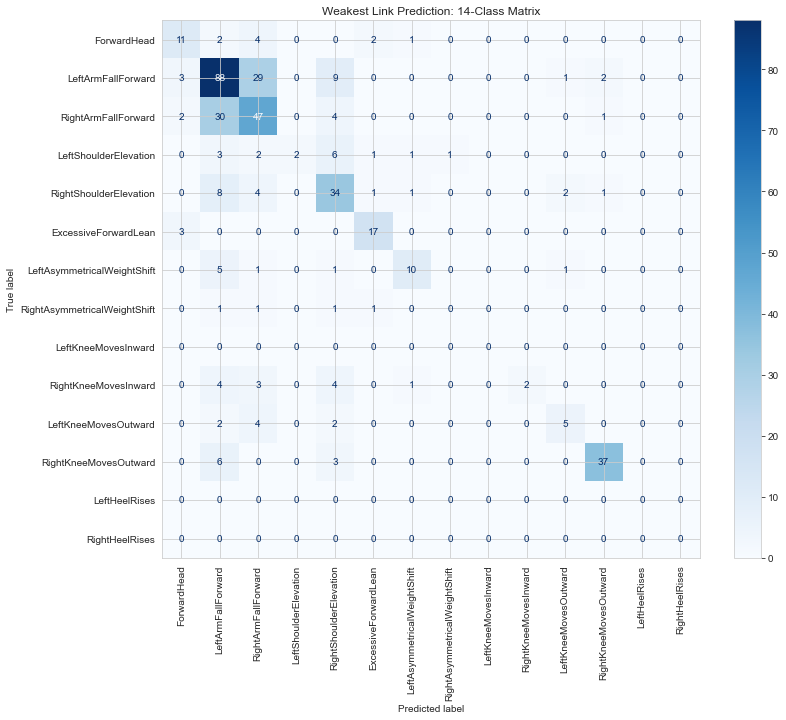

/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/a

{'F1_Mean': 0.628210178774182, 'F1_Std': 0.02195034912233877, 'Accuracy_Mean': 0.6412725432462273, 'Precision_Mean': 0.6317345892131235, 'Recall_Mean': 0.6412725432462273}


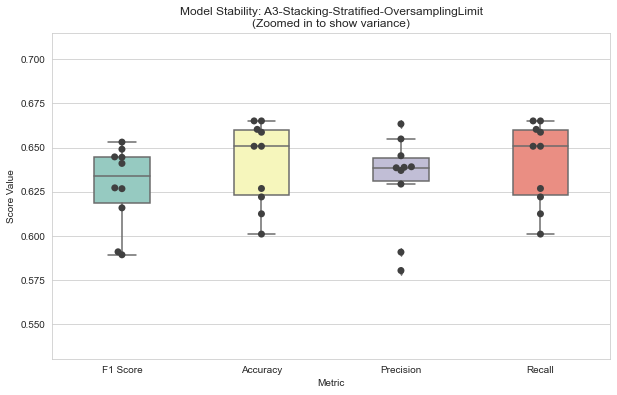

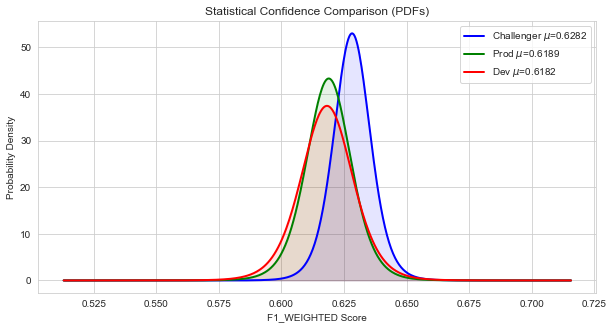

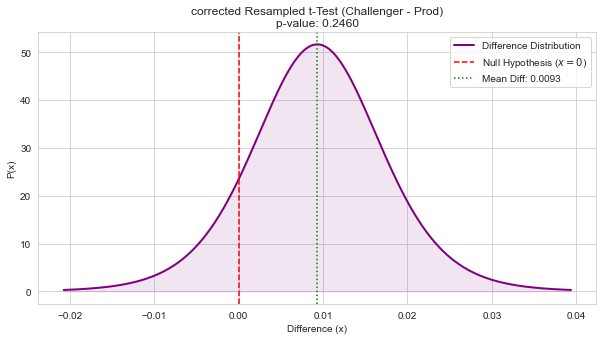

Difference not significant (p=0.2460)
New Best! 0.628210178774182 > 0.6181784619398688. Updating models on DagsHub


2026/02/24 11:53:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 11:53:33 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/9w/6516vw7x2gbc3llv8dbzm6vw0000gn/T/tmp3ghlnlg4/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
Registered model 'Project_Model_A3_V2' already exists. Creating a new version of this model...
2026/02/24 11:53:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Project_Model_A3_V2, version 12
Created version '12' of model 'Project_Model_A3_V2'.
/var/folders/9w/6516vw7x2gbc3llv8dbzm6vw0000gn/T/ipykernel_55342/900305127.py:103: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be remo

New model beat current @dev uploading to DagsHub
🏃 View run A3-Training-Ensemble-Oversampling at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/e4f6e9bfc73e49e497823fa177424516
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


In [166]:



from mlflow.models import infer_signature


with mlflow.start_run(run_name="A3-Training-Ensemble-Oversampling") as run:
    mlflow.log_params(config)


    y = df_final['WeakestLink']
    cheating_cols = weak_link_columns + [
    'WeakestLink', 'ID', 'Date', 'SCORE', 'AimoScore', 
    'EstimatedScore', 'label score'
    ]

    X = df_final.drop(columns=[c for c in cheating_cols if c in df_final.columns], errors='ignore')
    X = X.select_dtypes(include=[np.number])

    # Check which classes are too rare for 10-fold CV
    counts = y.value_counts()
    rare_classes = counts[counts < 10].index
    
    if len(rare_classes) > 0:
        print(f"⚠️ Removing ultra-rare classes to stabilize 10-fold CV: {list(rare_classes)}")
        # Filter the dataframe
        df_final = df_final[~df_final['WeakestLink'].isin(rare_classes)]
        
        # RE-REFRESH both y and X from the filtered df_final
        y = df_final['WeakestLink']
        # We drop the cheating columns again to ensure X matches the new y rows
        X = df_final.drop(columns=[c for c in cheating_cols if c in df_final.columns], errors='ignore')
    


    
    report_oversampling(X, y)
    
    model = fit_stacking_classifier(X, y, kf)

    print("Model Done")

    model.fit(X, y)

    print("Fitting done")

    confuse_matrix(X, y, model)


    f1_scores = cross_val_score(model, X, y, cv=kf, scoring='f1_weighted')
    accuracy = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    precision = cross_val_score(model, X, y, cv=kf, scoring='precision_weighted')
    recall = cross_val_score(model, X, y, cv=kf, scoring='recall_weighted')

    results = {
        "F1_Mean": f1_scores.mean(),
        "F1_Std": f1_scores.std(),
        "Accuracy_Mean": accuracy.mean(),
        "Precision_Mean": precision.mean(),
        "Recall_Mean": recall.mean()
    }
    print(results)

    crossval_boxplots(f1_scores,accuracy,precision,recall)

    mlflow.log_metrics(results)

    mlflow.log_artifact("boxplot.png")
    mlflow.log_artifact("matrix.png")

    current_scores_df = pd.DataFrame({
    'f1_weighted': f1_scores,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall
    })
    current_scores_df.to_csv("cv_fold_scores.csv", index=False)
    mlflow.log_artifact("cv_fold_scores.csv")

    # Call the statistical check using f1_weighted
    is_better, p_val = utils.is_challenger_statistically_better(
        current_scores_df, 
        metric="f1_weighted"
    )

    mlflow.log_artifact("model_confidence_comparison.png")

    mlflow.log_artifact("challenger_vs_prod_ttest.png")

    # Before logging, grab a sample of X (which has 38 columns)
    input_example = X.iloc[:5] 
    
    # Predict once to get the output format
    prediction_example = model.predict(input_example)
    
    # Explicitly infer the signature using the 38-column input
    signature = infer_signature(input_example, prediction_example)

    if is_better:
        print(f"Challenger is statistically superior (p={p_val:.4f})")
    else:
        print(f"Difference not significant (p={p_val:.4f})")

    if utils.auto_check_challenger(run.info.run_id, metric_name="F1_Mean"):
        mlflow.sklearn.log_model(model, "model", signature=signature, input_example=input_example, registered_model_name="Project_Model_A3_V2")
        latest_v = utils.client.get_latest_versions("Project_Model_A3_V2")[0].version
        utils.client.set_registered_model_alias("Project_Model_A3_V2", "dev", latest_v)
        print("New model beat current @dev uploading to DagsHub")
    else:
        print("Did not beat current @dev, model not uploaded to Dagshub")